# EV Market Decarbonization Analysis: Extract, Transform & Findings

**Author:** Narda Parama Agung Noviantoro

This notebook scrapes and cleans electric vehicle specification data from [ev-database.org](https://ev-database.org), then explores a core sustainability question: is the EV market actually becoming more efficient and more affordable, or is progress uneven?

Using efficiency (Wh/km), range, battery capacity, price, and availability data across 200 EV models, this analysis looks at whether cleaner transport is genuinely becoming accessible, or whether efficiency gains are still gated behind a price premium.

For the Load stage and equivalent SQL-based analysis, see [`ev_market_decarbonization_analysis_load.sql`](./ev_market_decarbonization_analysis_load.sql).

## A. Extract

Selenium automates a Chrome browser to load ev-database.org and capture the rendered page HTML (the site loads vehicle data dynamically, so a static request alone wouldn't work).

BeautifulSoup then parses that HTML to extract 6 fields per vehicle: Car Model, Efficiency (Wh/km), Range (km), Battery (kWh), Price (GBP), and Availability.

A try/except block handles any field that's occasionally missing on the page, logging `None` instead of breaking the loop.

In [1]:
import time
import pandas as pd
from selenium import webdriver
from bs4 import BeautifulSoup

model = []
efficiency = []
range_km = []
battery = []
price = []
availability = []

driver = webdriver.Chrome()

url = 'https://ev-database.org/#group=vehicle-group&rs-pr=10000_100000&rs-er=0_1000&rs-ld=0_1000&rs-ac=2_23&rs-dcfc=0_400&rs-ub=10_200&rs-tw=0_3000&rs-ef=100_350&rs-sa=-1_5&rs-w=1000_3500&rs-c=0_5000&rs-y=2010_2030&s=1&p=0-200'

driver.get(url)

time.sleep(10)

html = driver.page_source

soup = BeautifulSoup(html, "html.parser")

boxes = soup.find_all('div', {'class':'list-item'})

for box in boxes:
    try:
        car_model = box.find('span',{'class':'hidden'}).get_text()
        model.append(car_model)
    except:
        model.append(None)
    try:
        efficience = box.find('span',{'class':'efficiency'}).get_text()
        efficiency.append(efficience)
    except:
        efficiency.append(None)
    try:
        range_value = box.find('span',{'class':'erange_real'}).get_text()
        range_km.append(range_value)
    except:
        range_km.append(None)
    try:
        batre = box.find('span',{'class':'battery_p'}).get_text()
        battery.append(batre)
    except:
        battery.append(None)
    try:
        price_tag = box.find('span',{'class':'country_uk'}).get_text()
        price.append(price_tag)
    except:
        price.append(None)
    try:
        available = box.find('div',{'class':'availability current'})
        if available is not None:
            availability.append('Available')
        else: 
            raise Exception
    except:
        try:
            available = box.find('div',{'class':'availability archive'})
            if available is not None:
                availability.append('Discontinued')
            else: 
                raise Exception
        except:
            availability.append(None)




driver.quit()

Storing the scraped results in a Pandas DataFrame.

In [2]:
df = pd.DataFrame(
    {
        'Car Model':model,
        'Efficiency (Wh/km)':efficiency,
        'Range (km)':range_km,
        'Battery (kWh)':battery,
        'Price (GBP)':price,
        'Availability':availability
        
        
    })

df.head()

,Car Model,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP),Availability
0,Tesla Model 3 RWD,133 Wh/km,450 km,60.0 kWh,"£37,990",Available
1,MG MG4 Electric 64 kWh,171 Wh/km,360 km,61.7 kWh,"£29,745",Discontinued
2,BMW iX xDrive40,197 Wh/km,360 km,71.0 kWh,"£69,905",Discontinued
3,CUPRA Born 150 kW - 58 kWh,166 Wh/km,350 km,58.0 kWh,"£34,125",Discontinued
4,Fiat 500e Hatchback 42 kWh,159 Wh/km,235 km,37.3 kWh,"£20,245",Available


Saving the raw scraped data to CSV. This preserves the original, unprocessed output as a checkpoint before any cleaning happens.

In [3]:
df.to_csv('raw_data_EV_Sustainability.csv')

## B. Transform

Reading the raw CSV back in as a fresh starting point for cleaning, kept in its own variable (`df_ev`) separate from the original scrape.

In [4]:
df_ev = pd.read_csv('raw_data_EV_Sustainability.csv', index_col=0)

A first look at the full raw dataset.

In [5]:
df_ev

,Car Model,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP),Availability
0,Tesla Model 3 RWD,133 Wh/km,450 km,60.0 kWh,"£37,990",Available
1,MG MG4 Electric 64 kWh,171 Wh/km,360 km,61.7 kWh,"£29,745",Discontinued
2,BMW iX xDrive40,197 Wh/km,360 km,71.0 kWh,"£69,905",Discontinued
3,CUPRA Born 150 kW - 58 kWh,166 Wh/km,350 km,58.0 kWh,"£34,125",Discontinued
4,Fiat 500e Hatchback 42 kWh,159 Wh/km,235 km,37.3 kWh,"£20,245",Available
...,...,...,...,...,...,...
195,Audi A6 Avant e-tron performance,165 Wh/km,575 km,94.9 kWh,"£71,740",Available
196,Mercedes-Benz CLA 350 4MATIC,148 Wh/km,575 km,85.0 kWh,"£51,800",Available
197,Audi Q4 e-tron 45,183 Wh/km,420 km,77.0 kWh,"£51,360",Discontinued
198,Honda Super-N,151 Wh/km,185 km,28.0 kWh,"£18,995",Available


Previewing the first 20 rows.

In [6]:
df_ev.head(20)

,Car Model,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP),Availability
0,Tesla Model 3 RWD,133 Wh/km,450 km,60.0 kWh,"£37,990",Available
1,MG MG4 Electric 64 kWh,171 Wh/km,360 km,61.7 kWh,"£29,745",Discontinued
2,BMW iX xDrive40,197 Wh/km,360 km,71.0 kWh,"£69,905",Discontinued
3,CUPRA Born 150 kW - 58 kWh,166 Wh/km,350 km,58.0 kWh,"£34,125",Discontinued
4,Fiat 500e Hatchback 42 kWh,159 Wh/km,235 km,37.3 kWh,"£20,245",Available
5,XPENG L03 RWD Long Range,165 Wh/km,420 km,69.5 kWh,NaN,Available
6,CUPRA Born 170 kW - 77 kWh,171 Wh/km,450 km,77.0 kWh,"£39,625",Discontinued
7,BMW i3 50 xDrive,152 Wh/km,715 km,108.7 kWh,"£53,005",Available
8,BMW iX3 50 xDrive,169 Wh/km,645 km,108.7 kWh,"£58,755",Available
9,Mercedes-Benz CLA 250+,145 Wh/km,585 km,85.0 kWh,"£43,250",Available


Checking the dataset's shape, column types, and missing values before cleaning.

**Structure Summary:** 200 rows, 6 columns. All columns are currently stored as strings. `Price (GBP)` has 32 missing values and `Availability` has 3, both due to information genuinely not being available on the source page (mainly upcoming/unreleased models).

In [7]:
df_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Car Model           200 non-null    str  
 1   Efficiency (Wh/km)  200 non-null    str  
 2   Range (km)          200 non-null    str  
 3   Battery (kWh)       200 non-null    str  
 4   Price (GBP)         170 non-null    str  
 5   Availability        197 non-null    str  
dtypes: str(6)
memory usage: 9.5 KB


Cleaning `Efficiency (Wh/km)`: stripping the unit text and converting to a numeric type.

In [8]:
df_ev['Efficiency (Wh/km)'] = df_ev['Efficiency (Wh/km)'].str.replace('Wh/km','')
df_ev['Efficiency (Wh/km)'] = df_ev['Efficiency (Wh/km)'].astype(float)

Cleaning `Range (km)`: stripping the unit text and converting to a numeric type.

In [9]:
df_ev['Range (km)'] = df_ev['Range (km)'].str.replace('km','')
df_ev['Range (km)'] = df_ev['Range (km)'].astype(float)

Cleaning `Battery (kWh)`: stripping the unit text and converting to a numeric type.

In [10]:
df_ev['Battery (kWh)'] = df_ev['Battery (kWh)'].str.replace('kWh','')
df_ev['Battery (kWh)'] = df_ev['Battery (kWh)'].astype(float)

Cleaning `Price (GBP)`: stripping the currency symbol, thousands separators, and asterisks (used on the source site to flag estimated prices), then converting to a numeric type.

In [11]:
df_ev['Price (GBP)'] = df_ev['Price (GBP)'].str.replace('£','')
df_ev['Price (GBP)'] = df_ev['Price (GBP)'].str.replace(',','')
df_ev['Price (GBP)'] = df_ev['Price (GBP)'].str.replace('*','')
df_ev['Price (GBP)'] = df_ev['Price (GBP)'].astype(float)

Previewing the first 20 rows after cleaning.

In [12]:
df_ev.head(20)

,Car Model,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP),Availability
0,Tesla Model 3 RWD,133.0,450.0,60.0,37990.0,Available
1,MG MG4 Electric 64 kWh,171.0,360.0,61.7,29745.0,Discontinued
2,BMW iX xDrive40,197.0,360.0,71.0,69905.0,Discontinued
3,CUPRA Born 150 kW - 58 kWh,166.0,350.0,58.0,34125.0,Discontinued
4,Fiat 500e Hatchback 42 kWh,159.0,235.0,37.3,20245.0,Available
5,XPENG L03 RWD Long Range,165.0,420.0,69.5,NaN,Available
6,CUPRA Born 170 kW - 77 kWh,171.0,450.0,77.0,39625.0,Discontinued
7,BMW i3 50 xDrive,152.0,715.0,108.7,53005.0,Available
8,BMW iX3 50 xDrive,169.0,645.0,108.7,58755.0,Available
9,Mercedes-Benz CLA 250+,145.0,585.0,85.0,43250.0,Available


Re-checking the dataset after cleaning.

**Structure Summary:** `Efficiency`, `Range`, `Battery`, and `Price` are now `float64`. `Car Model` and `Availability` remain strings, as expected. Missing values were intentionally kept as `NaN` rather than dropped or imputed, to preserve valid data in the rest of each row.

In [13]:
df_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car Model           200 non-null    str    
 1   Efficiency (Wh/km)  200 non-null    float64
 2   Range (km)          200 non-null    float64
 3   Battery (kWh)       200 non-null    float64
 4   Price (GBP)         170 non-null    float64
 5   Availability        197 non-null    str    
dtypes: float64(4), str(2)
memory usage: 9.5 KB


Summary statistics across the numeric columns, a sanity check that the cleaning worked correctly (no impossible values, no leftover parsing errors).

**Overall:** all ranges are realistic for real-world EVs (e.g. efficiency 130–294 Wh/km, price £11,990–£180,860), confirming the cleaning was successful.

In [14]:
df_ev.describe()

,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP)
count,200.000000,200.00000,200.000000,170.000000
mean,172.130000,409.92500,70.704000,43576.758824
std,20.281761,105.65122,20.030451,19732.819915
min,130.000000,165.00000,24.000000,11990.000000
25%,160.000000,345.00000,58.000000,32099.750000
50%,169.000000,410.00000,74.400000,39945.000000
75%,181.250000,471.25000,80.150000,51267.500000
max,294.000000,720.00000,141.000000,180860.000000


Exporting the cleaned dataset to CSV, ready for analysis.

In [15]:
df_ev.to_csv('clean_data_EV_Sustainability.csv', index = False)

## Key Findings

Loading the cleaned dataset as the starting point for analysis.

In [16]:
df_findings = pd.read_csv('clean_data_EV_Sustainability.csv')
df_findings.head()

,Car Model,Efficiency (Wh/km),Range (km),Battery (kWh),Price (GBP),Availability
0,Tesla Model 3 RWD,133.0,450.0,60.0,37990.0,Available
1,MG MG4 Electric 64 kWh,171.0,360.0,61.7,29745.0,Discontinued
2,BMW iX xDrive40,197.0,360.0,71.0,69905.0,Discontinued
3,CUPRA Born 150 kW - 58 kWh,166.0,350.0,58.0,34125.0,Discontinued
4,Fiat 500e Hatchback 42 kWh,159.0,235.0,37.3,20245.0,Available


Using matplotlib.pyplot to visualize each finding alongside its underlying data, using bar charts to make the comparisons easier to read at a glance.

In [17]:
import matplotlib.pyplot as plt

### Is There a Price Penalty for Efficiency?

Grouping vehicles into price tiers and comparing average efficiency across them shows whether the most efficient EVs are still gated behind a premium price point, or whether efficient tech has trickled down to more affordable models.

In [18]:
df_findings['Price Category'] = pd.cut(
    df_findings['Price (GBP)'],
    bins=[0, 30000, 50000, 100000, 1000000],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury']
)

df_findings.groupby('Price Category', observed=True)['Efficiency (Wh/km)'].mean()

Price Category
Budget       163.088235
Mid-range    168.395604
Premium      177.463415
Luxury       210.750000
Name: Efficiency (Wh/km), dtype: float64

The chart below makes the trend easier to see: efficiency worsens steadily as price tier increases. 

Note: lower Wh/km indicates higher efficiency, meaning the vehicle uses less energy per kilometer traveled.

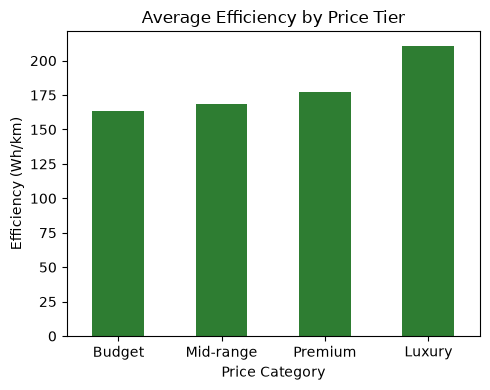

In [19]:
price_efficiency = df_findings.groupby('Price Category', observed=True)['Efficiency (Wh/km)'].mean()

plt.figure(figsize=(5, 4))
price_efficiency.plot(kind='bar', color='#2E7D32')
plt.title('Average Efficiency by Price Tier')
plt.ylabel('Efficiency (Wh/km)')
plt.xlabel('Price Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** There's a clear price penalty. Average efficiency gets *worse* as price increases (Budget: 163.1 Wh/km → Luxury: 210.8 Wh/km). Rather than efficient technology trickling down to affordable models, the opposite pattern holds: budget EVs are actually the most efficient segment, while luxury EVs trade efficiency for size, weight, and performance. This suggests decarbonization gains are currently concentrated at the accessible end of the market, not gated behind a price premium.

### Which Brands Lead on Efficiency?

Comparing average efficiency by brand highlights which manufacturers are prioritizing energy efficiency versus performance or luxury positioning.

In [20]:
df_findings['Brand'] = df_findings['Car Model'].str.split(' ', n=1).str[0]

df_findings.groupby('Brand')['Efficiency (Wh/km)'].mean().sort_values().head(10)

Brand
Honda       151.000000
Dacia       151.000000
Mini        155.000000
Tesla       156.000000
Dongfeng    157.000000
Renault     159.250000
Lucid       163.000000
Fiat        163.500000
CUPRA       164.666667
Hyundai     164.846154
Name: Efficiency (Wh/km), dtype: float64

The chart below shows the top 10 brands by average efficiency, from most to least efficient.

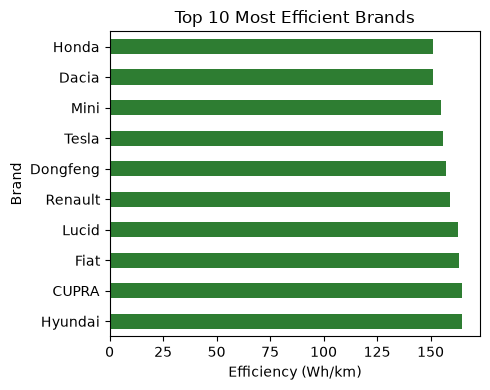

In [21]:
brand_efficiency = df_findings.groupby('Brand')['Efficiency (Wh/km)'].mean().sort_values().head(10)

plt.figure(figsize=(5, 4))
brand_efficiency.plot(kind='barh', color='#2E7D32')
plt.title('Top 10 Most Efficient Brands')
plt.xlabel('Efficiency (Wh/km)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** The most efficient brands are a mix of budget-focused manufacturers (Dacia, Honda, Mini) and Tesla, notable because Tesla sits near the top of this list (156 Wh/km) despite not being a budget brand, suggesting efficient engineering rather than just small/cheap vehicles is driving its position. Luxury-oriented brands are absent from this top-10 list entirely, reinforcing the price-tier finding above.

### Which Models Deliver the Most Range per kWh of Battery?

Battery production is the most resource- and mining-intensive part of an EV. A model that delivers more range per kWh is achieving efficiency through genuine engineering, not just a bigger battery, a meaningful distinction for assessing real sustainability progress.

In [22]:
df_findings['Range per kWh'] = df_findings['Range (km)'] / df_findings['Battery (kWh)']

df_findings.sort_values('Range per kWh', ascending=False)[['Car Model', 'Range per kWh']].head(10)

,Car Model,Range per kWh
26,Tesla Model 3 RWD,7.666667
0,Tesla Model 3 RWD,7.500000
13,Tesla Model 3 Premium RWD,7.341772
34,Tesla Model 3 Long Range RWD,7.333333
91,Tesla Model 3 Premium AWD,7.025316
93,Tesla Model 3 RWD,7.017544
149,Tesla Model 3 Long Range AWD,7.000000
184,Mercedes-Benz CLA 200,6.896552
9,Mercedes-Benz CLA 250+,6.882353
121,Dacia Spring Electric 70,6.875000


The chart below shows the top 10 models by range delivered per kWh of battery.

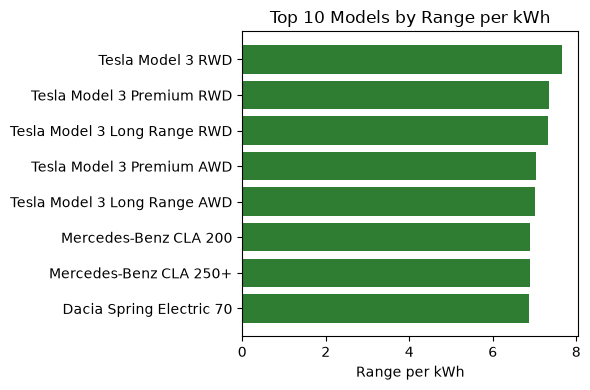

In [23]:
top_range = df_findings.sort_values('Range per kWh', ascending=False).head(10)

plt.figure(figsize=(6, 4))
plt.barh(top_range['Car Model'], top_range['Range per kWh'], color='#2E7D32')
plt.title('Top 10 Models by Range per kWh')
plt.xlabel('Range per kWh')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** Tesla Model 3 variants dominate this ranking, taking 7 of the top 10 spots, a striking result given Tesla's efficiency score (156 Wh/km) was already near the top of the brand comparison. This indicates Tesla's advantage isn't just marginal efficiency, but a meaningfully better ratio of usable range to battery size than most competitors, achieved through engineering rather than simply installing a larger battery.

### Overall Takeaway
Across all three analyses, Tesla and budget-segment brands consistently outperform on efficiency, while luxury EVs lag. This suggests the EV market's progress toward genuine decarbonization is currently led by accessible and engineering-focused models, not premium ones. This is a meaningful distinction for anyone assuming "more expensive = more advanced" in the clean transport space.